# Imports

In [25]:
# PyTorch
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as nnFunc
import torch.amp as amp
# General
import numpy as np
import matplotlib.pyplot as plt
# Optimizer
import torch.optim as optim
# pretty print
from pprint import pprint

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 13.0


## Dataset

This code uses the CIFAR-10 dataset.
(https://www.cs.toronto.edu/~kriz/cifar.html)

## 1. Transform setting
The original images are in PIL (0 to 255 for each pixel). First we convert it to a tensor format (0 to 1). Then to make the data to be zero centering, we make the range to be between -1 to 1. If we use the following equation for each data, we can make it zero centered:
\begin{equation}
  output = \frac{input - mean}{std}
\end{equation}
This is being done by setting the `mean` and `standard deviation` to be 0.5.

In [26]:
transform = transforms.Compose([  transforms.RandomHorizontalFlip(),
                                transforms.RandomCrop(32, padding=4),
                                transforms.ToTensor(),
                                transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                                ])

## 2. Making the training set
Now we load the actual dataset and make the training dataset.
1. Load CIFAR10 dataset (Download and prepare dataset)
    1. Put it in `./data_CIFAR10` directory.
    2. Download it
    3. Do the specified transformation on the dataset
2. Create the data loader (pipelining settings)
    1. Brake it to batches with size of 32
    2. Shuffle the deck in every epoch
    3. Use 4 number of workers to make the training faster


In [27]:
batchSize = 256
numberOfWorkers = 0

trainSet = torchvision.datasets.CIFAR10(root='./data_CIFAR10',
                                        train=True,
                                        download=True,
                                        transform = transform)

trainLoader = torch.utils.data.DataLoader(trainSet,
                                          batch_size=batchSize,
                                          shuffle=True,
                                          num_workers=numberOfWorkers,
                                          pin_memory=True,
                                          persistent_workers=False)

## 3. Making the test set
Now making the test set. The procedure is the same as making the training set with some minor modifications.

In [28]:
testSet = torchvision.datasets.CIFAR10(root='./data_CIFAR10',
                                       train=False,
                                       download=True,
                                       transform=transform)

testLoader = torch.utils.data.DataLoader(testSet,
                                         batch_size=batchSize,
                                         shuffle=False,
                                         num_workers=numberOfWorkers,
                                         pin_memory=True,
                                         persistent_workers=False) # Updated here too
viz_batchSize = 4
vizLoader = torch.utils.data.DataLoader(testSet, batch_size=viz_batchSize, shuffle=True)

## 4. The classes

In [29]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
pprint(classes)

('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## DEUBG1
Showing some of the images from the dataset.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8183348].


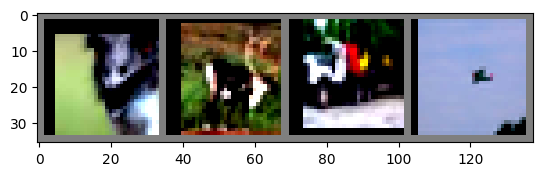

'bird  deer  truck plane'


In [30]:
# functions to show an image
def imshow(img):
  img = img / 2 + 0.5 # unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()
# get some random training images
dataiter = iter(vizLoader)
images, labels = next(dataiter)
# show images
imshow(torchvision.utils.make_grid(images))
# print labels
pprint(' '.join(f'{classes[labels[j]]:5s}' for j in range(viz_batchSize)))

## 5. Defining the CNN model

In [31]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)
    self.fc1 = nn.Linear(64 * 4 * 4, 64)
    self.fc2 = nn.Linear(64, 10)

  def forward(self, x):
    x = self.pool1(nnFunc.relu(self.conv1(x)))
    x = self.pool2(nnFunc.relu(self.conv2(x)))
    x = nnFunc.relu(self.conv3(x))

    x = x.view(-1, 64 * 4 * 4)

    x = nnFunc.relu(self.fc1(x))
    x = self.fc2(x)
    
    return x

## 6. Instansiating the CNN model


In [32]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
net = Net()
net.apply(init_weights)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

## 7. Move the model to GPU

In [33]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [34]:
net.to(device)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

## 8. Degine loss function and optimizer

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=10)

## 9. Traing the network

In [36]:
scaler = amp.GradScaler('cuda')

epochs = 100
printFrequency = len(trainLoader) // 4

for epoch in range(epochs):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # --- TRAINING PHASE ---
    for i, data in enumerate(trainLoader, 0):
        inputs, labels = data[0].to(device, non_blocking=True), data[1].to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with amp.autocast('cuda'):
            outputs = net(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item()
        
        if i % printFrequency == (printFrequency - 1):
            accuracy = 100 * correct / total
            print(f'Epoch {epoch + 1} | Batch {i + 1}/{len(trainLoader)} | loss: {running_loss / printFrequency:.3f} | acc: {accuracy:.2f}%')
            running_loss, correct, total = 0.0, 0, 0

    # --- VALIDATION PHASE ---
    net.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in testLoader:
            images, labels = data[0].to(device), data[1].to(device)
            with amp.autocast('cuda'):
                outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    current_lr = optimizer.param_groups[0]['lr']
    print(f'>> Epoch {epoch + 1} SUMMARY: Val Acc: {val_acc:.2f}% | Current LR: {current_lr}')
    
    # --- AUTOMATIC LR DROP ---
    scheduler.step(val_acc)

print('Finished Training')

Epoch 1 | Batch 49/196 | loss: 3.281 | acc: 19.40%
Epoch 1 | Batch 98/196 | loss: 1.880 | acc: 31.38%
Epoch 1 | Batch 147/196 | loss: 1.695 | acc: 37.87%
Epoch 1 | Batch 196/196 | loss: 1.629 | acc: 40.38%
>> Epoch 1 SUMMARY: Val Acc: 41.42% | Current LR: 0.001
Epoch 2 | Batch 49/196 | loss: 1.559 | acc: 42.85%
Epoch 2 | Batch 98/196 | loss: 1.496 | acc: 45.25%
Epoch 2 | Batch 147/196 | loss: 1.466 | acc: 46.25%
Epoch 2 | Batch 196/196 | loss: 1.441 | acc: 47.99%
>> Epoch 2 SUMMARY: Val Acc: 48.45% | Current LR: 0.001
Epoch 3 | Batch 49/196 | loss: 1.404 | acc: 49.59%
Epoch 3 | Batch 98/196 | loss: 1.364 | acc: 51.27%
Epoch 3 | Batch 147/196 | loss: 1.307 | acc: 53.07%
Epoch 3 | Batch 196/196 | loss: 1.280 | acc: 54.09%
>> Epoch 3 SUMMARY: Val Acc: 52.99% | Current LR: 0.001
Epoch 4 | Batch 49/196 | loss: 1.285 | acc: 54.15%
Epoch 4 | Batch 98/196 | loss: 1.239 | acc: 55.75%
Epoch 4 | Batch 147/196 | loss: 1.225 | acc: 56.61%
Epoch 4 | Batch 196/196 | loss: 1.222 | acc: 56.51%
>> Epoch

## 10. Test the network on the test data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].


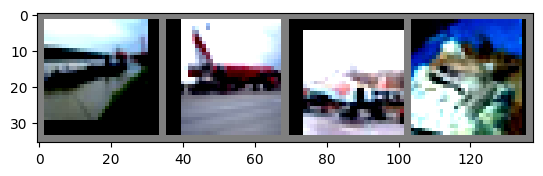

GroundTruth:  ship  plane plane frog 


In [37]:
dataIter = iter(vizLoader)
images, labels = next(dataIter)
# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(viz_batchSize)))

In [38]:
images, labels = images.to(device), labels.to(device)

outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j].item()]:5s}' for j in range(len(predicted))))

Predicted:  ship  truck plane frog 


## 11. Test the network on the whole dataset

In [39]:
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for data in testLoader:
        images, labels = data[0].to(device), data[1].to(device)
        
        outputs = net(images)
        
        # 1. Calculate the loss for this batch
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        # 2. Calculate accuracy as before
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate the average loss over all batches
avg_test_loss = test_loss / len(testLoader)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Loss: 0.6264
Test Accuracy: 79.27%


## 12. Check performance within each class

In [40]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testLoader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 77.9 %
Accuracy for class: car   is 86.0 %
Accuracy for class: bird  is 76.9 %
Accuracy for class: cat   is 59.2 %
Accuracy for class: deer  is 74.4 %
Accuracy for class: dog   is 74.8 %
Accuracy for class: frog  is 90.6 %
Accuracy for class: horse is 81.7 %
Accuracy for class: ship  is 85.8 %
Accuracy for class: truck is 90.3 %
